# AML Zero Shot Test
Exploring the zero shot capabilities of scGPT on out AML dataset

To-Do:

* Preprocess datasets
* Load model
* Get embeddings
* Downstream Tasks:
  * Cell type annotation
  * Batch correction
  * Imputation?
  * Gene function prediction
  * Gene network inference
  * Perturbation


## From Tutorial
## Import Dependencies

In [1]:
from pathlib import Path
import warnings

import scanpy as sc
import scib
import numpy as np
import sys

sys.path.insert(0, "../")

import scgpt as scg
import matplotlib.pyplot as plt
import anndata

plt.style.context('default')
warnings.simplefilter("ignore", ResourceWarning)

model_dir = Path("../save/scGPT_kidney")


/data/xu_lab_projectsx/Andrew/Foundation_Test/scGPT-1/tutorials/../scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/data/xu_lab_projectsx/Andrew/Foundation_Test/scGPT-1/tutorials/../scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Evaluation Function
Taken from the tutorial, mainly comparing avgBIO and avgBATCH

In [2]:
"""
Calculate the metrics for integration results
"""
def scib_eval(adata, batch_key, cell_type_key, embed_key):
    results = scib.metrics.metrics(
        adata,
        adata_int=adata,
        batch_key=batch_key,
        label_key=cell_type_key,
        embed=embed_key,
        isolated_labels_asw_=False,
        silhouette_=True,
        hvg_score_=False,
        graph_conn_=True,
        pcr_=True,
        isolated_labels_f1_=False,
        trajectory_=False,
        nmi_=True,  # use the clustering, bias to the best matching
        ari_=True,  # use the clustering, bias to the best matching
        cell_cycle_=False,
        kBET_=False,  # kBET return nan sometimes, need to examine
        ilisi_=False,
        clisi_=False,
    )
    result_dict = results[0].to_dict()
    
    # compute avgBIO metrics
    result_dict["avg_bio"] = np.mean(
        [
            result_dict["NMI_cluster/label"],
            result_dict["ARI_cluster/label"],
            result_dict["ASW_label"],
        ]
    )
    
    # compute avgBATCH metrics
    result_dict["avg_batch"] = np.mean(
        [
            result_dict["graph_conn"],
            result_dict["ASW_label/batch"],
        ]
    )
    
    result_dict = {k: v for k, v in result_dict.items() if not np.isnan(v)}
    
    return result_dict

## Prepare Datasets

In [3]:
smaple_data_path = '../data/AML_All_Samples.h5ad'
adata = sc.read_h5ad(smaple_data_path)
adata.var['gene_name'] = adata.var.index

gene_col = "gene_name"
cell_type_key = "AnnoCellType"
batch_key = "ID"
N_HVG = 3000

celltype_id_labels = adata.obs[cell_type_key].astype("category").cat.codes.values
adata = adata[celltype_id_labels >= 0]

org_adata = adata.copy()

# highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor='seurat_v3')
adata = adata[:, adata.var['highly_variable']]

/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/orig.ident' was written without encoding metadata.
  return func(*args, **kwargs)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/nCount_RNA' was written without encoding metadata.
  return func(*args, **kwargs)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/nFeature_RNA' was written without encoding metadata.
  return func(*args, **kwargs)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/ID' was written without encoding metadata.
  return func(*args, **kwargs)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/disease' was written without encoding metadata.
  return func(*args, **kwargs)
/users/wag9iz/.cond

## Generate Cell Embeddings

In [4]:
print(gene_col)
print(adata.var)

gene_name
            vf_vst_counts_mean  vf_vst_counts_variance  \
VWA1                  0.168021                0.682508   
RBP7                  0.171669                1.217411   
AADACL4               0.000088                0.000088   
AGMAT                 0.203552                0.709250   
CLCNKA                0.002457                0.003363   
...                        ...                     ...   
AC010326.2            0.000015                0.000015   
LINC01638             0.000022                0.000022   
AL021391.1            0.000022                0.000022   
Z97192.1              0.000015                0.000015   
AP000317.1            0.000110                0.000125   

            vf_vst_counts_variance.expected  \
VWA1                               0.267248   
RBP7                               0.274839   
AADACL4                            0.000092   
AGMAT                              0.344402   
CLCNKA                             0.002866   
...        

In [5]:
embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)
# attach the cell embedding to the original adata

/data/xu_lab_projectsx/Andrew/Foundation_Test/scGPT-1/tutorials/../scgpt/tasks/cell_emb.py:212: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["id_in_vocab"] = [


scGPT - INFO - match 2545/3000 genes in vocabulary of size 60697.


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/data/xu_lab_projectsx/Andrew/Foundation_Test/scGPT-1/tutorials/../scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 2125/2125 [00:57<00:00, 36.95it/s]


In [6]:
print("==== LAYERS ====")
print(list(embed_adata.layers.keys()))
print()

print("==== EMBEDDINGS (.obsm) ====")
print(list(embed_adata.obsm.keys()))
print()

==== LAYERS ====
[]

==== EMBEDDINGS (.obsm) ====
['X_harmony', 'X_pca', 'X_umap', 'X_umap.harmony', 'X_scGPT']



## Visualize Integration Performance

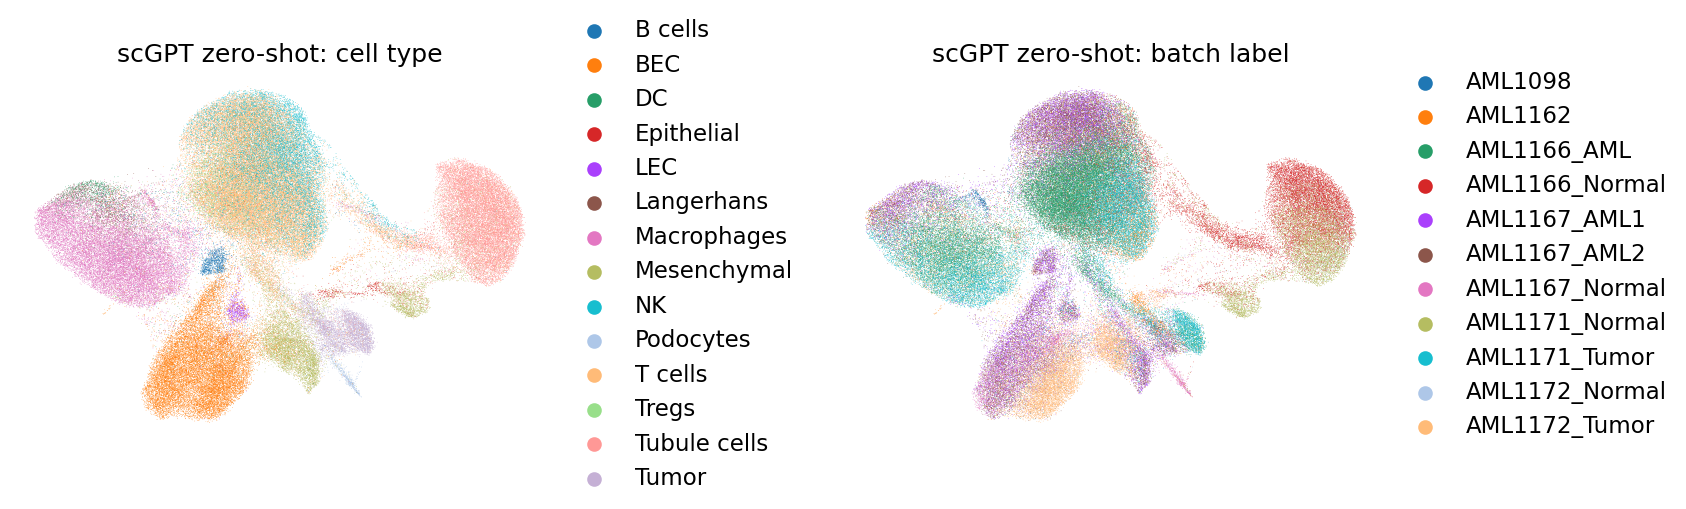

In [7]:
sc.pp.neighbors(embed_adata, use_rep="X_scGPT")
sc.tl.umap(embed_adata)
sc.pl.umap(embed_adata, 
           color=[cell_type_key, batch_key], 
           frameon=False, 
           wspace=0.4, 
           title=["scGPT zero-shot: cell type", "scGPT zero-shot: batch label"])

## Evaluate Integration Performance

In [8]:
scib_result_dict = scib_eval(
    embed_adata,
    batch_key=batch_key,
    cell_type_key=cell_type_key,
    embed_key="X_scGPT",
)
print("AvgBIO: {:.4f}".format(scib_result_dict["avg_bio"]))
print("AvgBATCH: {:.4f}".format(scib_result_dict["avg_batch"]))

Cluster for cluster_0.2 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:96: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed

PC regression...


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


Graph connectivity...


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future ve

AvgBIO: 0.5844
AvgBATCH: 0.9214


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

## Comparison with HVG+PCs

In [9]:
adata = org_adata.copy()
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor='seurat_v3')
adata = adata[:, adata.var['highly_variable']]
sc.pp.pca(adata, n_comps=40)
sc.pp.neighbors(adata, use_rep="X_pca")

/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


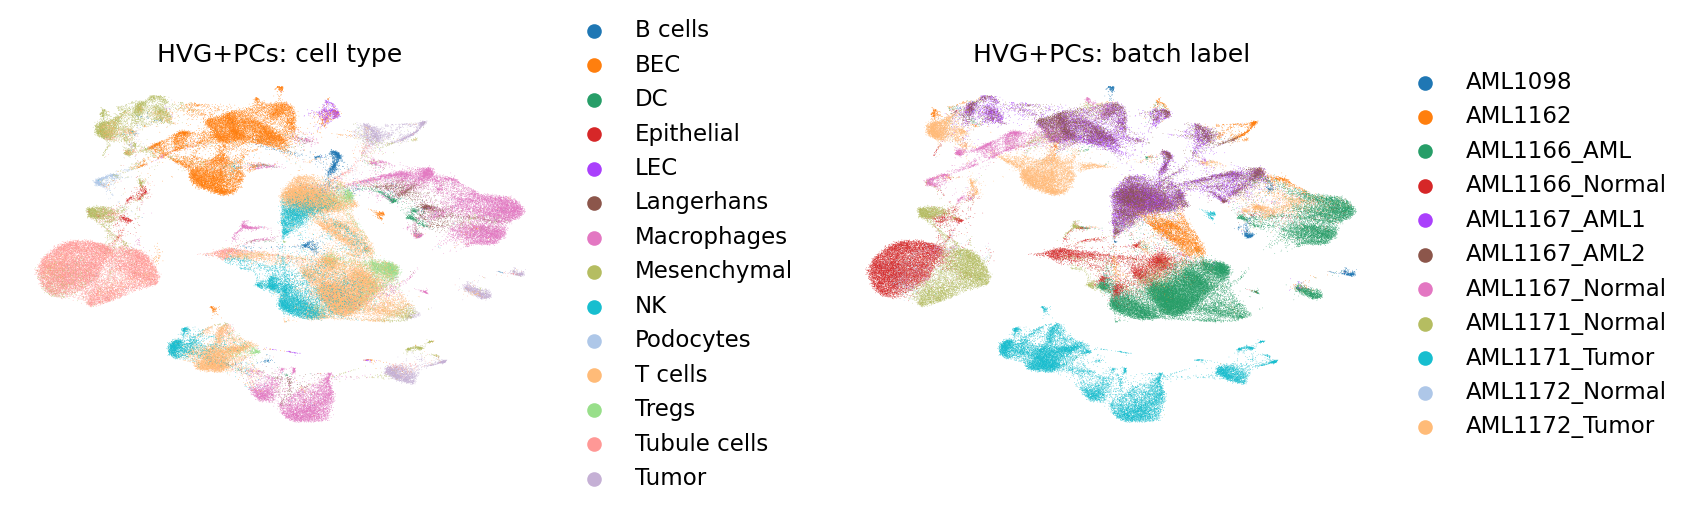

In [10]:
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
sc.pl.umap(adata, 
           color=[cell_type_key, batch_key], 
           frameon=False, 
           wspace=0.4, 
           title=["HVG+PCs: cell type", "HVG+PCs: batch label"])

In [11]:
scib_result_dict = scib_eval(
    adata,
    batch_key=batch_key,
    cell_type_key=cell_type_key,
    embed_key="X_pca",
)
print("AvgBIO: {:.4f}".format(scib_result_dict["avg_bio"]))
print("AvgBATCH: {:.4f}".format(scib_result_dict["avg_batch"]))

Cluster for cluster_0.2 with leiden
Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed

PC regression...
Graph connectivity...


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future ve

AvgBIO: 0.5064
AvgBATCH: 0.9190


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

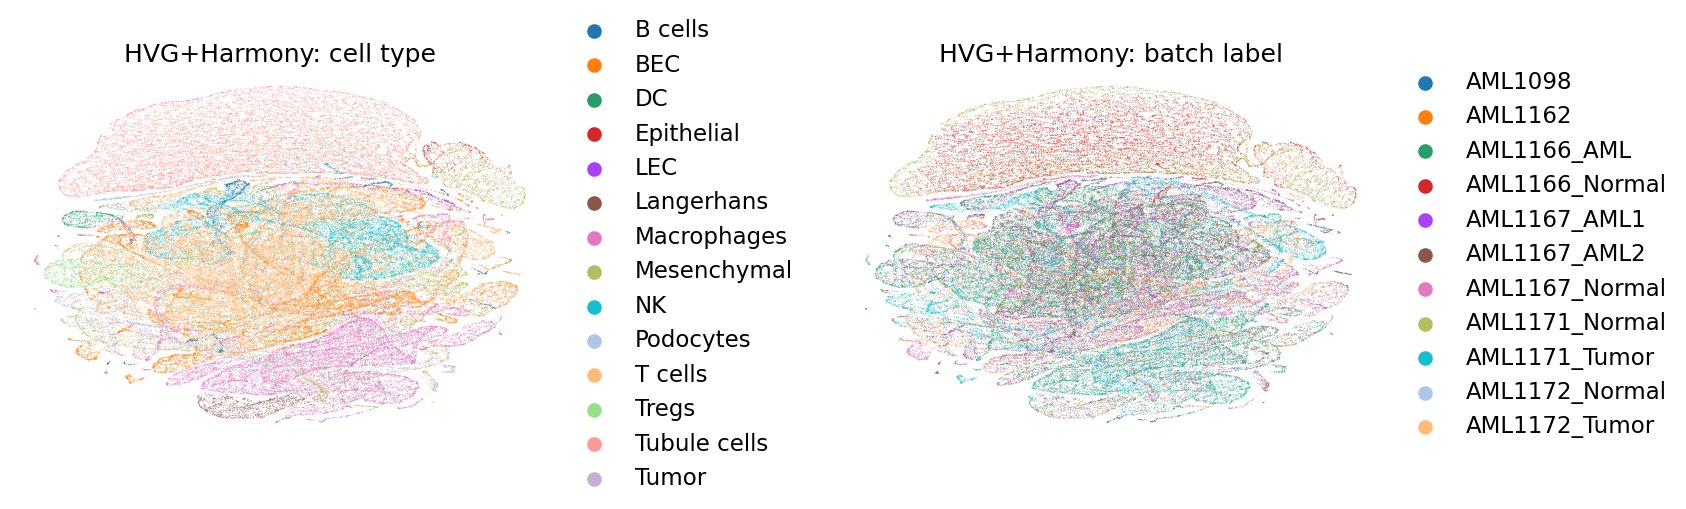

/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.2 in adata.obs
  call_cluster_function(


Cluster for cluster_0.2 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.4 in adata.obs
  call_cluster_function(


Cluster for cluster_0.4 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.6 in adata.obs
  call_cluster_function(


...

/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed

PC regression...
Graph connectivity...


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future ve

AvgBIO: 0.4340
AvgBATCH: 0.7983


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

In [13]:
sc.pp.neighbors(adata, use_rep="X_umap.harmony")
sc.tl.umap(adata)
sc.pl.umap(adata, 
           color=[cell_type_key, batch_key], 
           frameon=False, 
           wspace=0.4, 
           title=["HVG+Harmony: cell type", "HVG+Harmony: batch label"])
scib_result_dict = scib_eval(
    adata,
    batch_key=batch_key,
    cell_type_key=cell_type_key,
    embed_key="X_umap.harmony",
)
print("AvgBIO: {:.4f}".format(scib_result_dict["avg_bio"]))
print("AvgBATCH: {:.4f}".format(scib_result_dict["avg_batch"]))

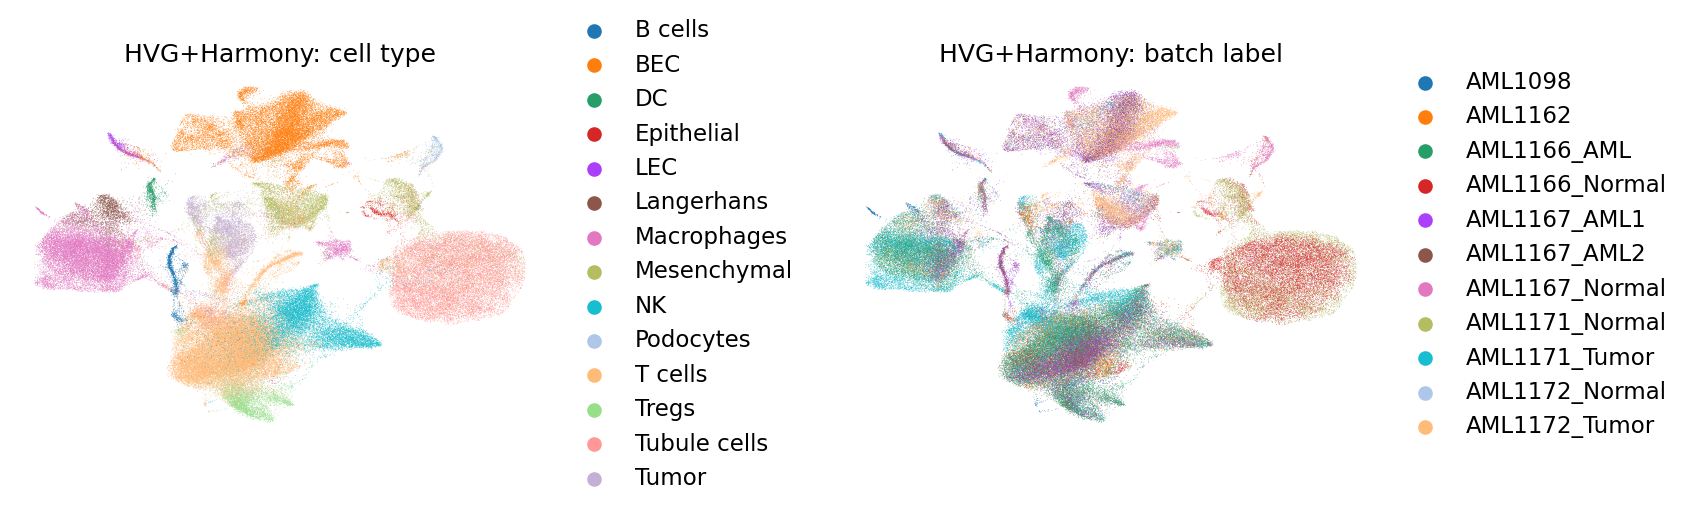

/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.2 in adata.obs
  call_cluster_function(


Cluster for cluster_0.2 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.4 in adata.obs
  call_cluster_function(


Cluster for cluster_0.4 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.6 in adata.obs
  call_cluster_function(


...

/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


Graph connectivity...


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future ve

AvgBIO: 0.6511
AvgBATCH: 0.9360


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstan

In [14]:
sc.pp.neighbors(adata, use_rep="X_harmony")
sc.tl.umap(adata)
sc.pl.umap(adata, 
           color=[cell_type_key, batch_key], 
           frameon=False, 
           wspace=0.4, 
           title=["HVG+Harmony: cell type", "HVG+Harmony: batch label"])
scib_result_dict = scib_eval(
    adata,
    batch_key=batch_key,
    cell_type_key=cell_type_key,
    embed_key="X_harmony",
)
print("AvgBIO: {:.4f}".format(scib_result_dict["avg_bio"]))
print("AvgBATCH: {:.4f}".format(scib_result_dict["avg_batch"]))

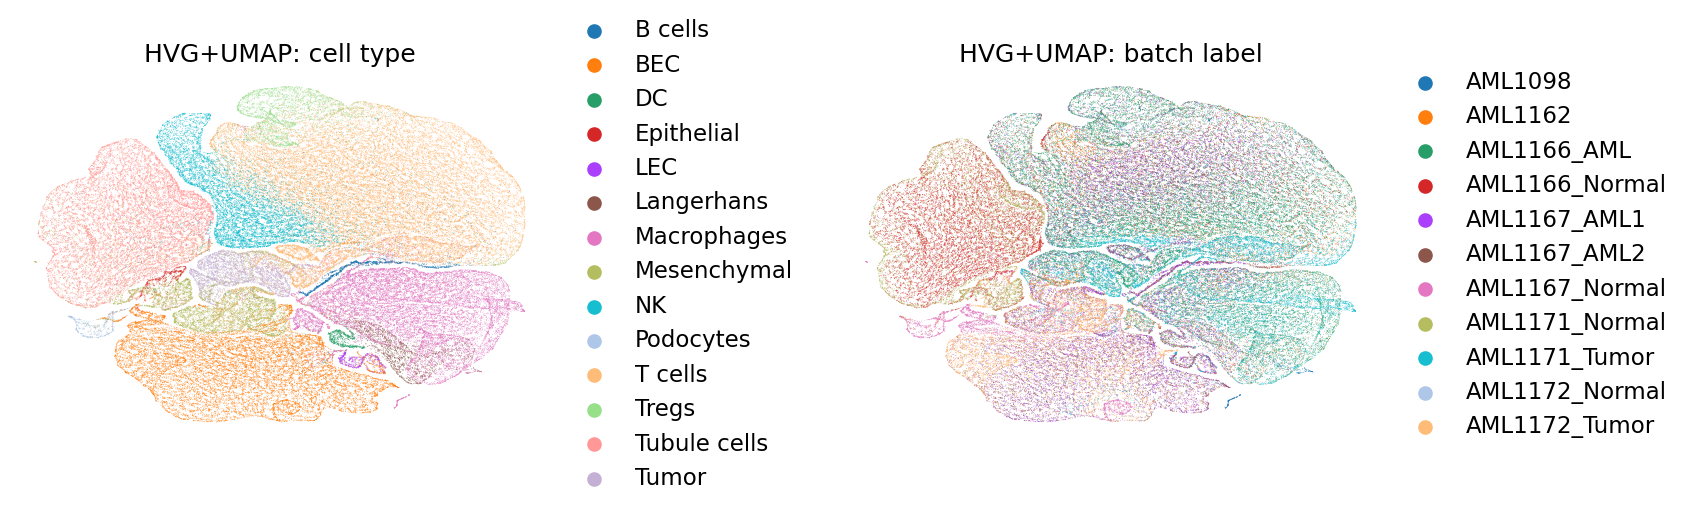

/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.2 in adata.obs
  call_cluster_function(


Cluster for cluster_0.2 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.4 in adata.obs
  call_cluster_function(


Cluster for cluster_0.4 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.6 in adata.obs
  call_cluster_function(


Cluster for cluster_0.6 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.8 in adata.obs
  call_cluster_function(


Cluster for cluster_0.8 with leiden


/users/wag9iz/.conda/envs/rtd/lib/python3.9/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_1.0 in adata.obs
  call_cluster_function(


Cluster for cluster_1.0 with leiden


In [ ]:
sc.pp.neighbors(adata, use_rep="X_umap")
sc.tl.umap(adata)
sc.pl.umap(adata, 
           color=[cell_type_key, batch_key], 
           frameon=False, 
           wspace=0.4, 
           title=["HVG+UMAP: cell type", "HVG+UMAP: batch label"])
scib_result_dict = scib_eval(
    adata,
    batch_key=batch_key,
    cell_type_key=cell_type_key,
    embed_key="X_umap",
)
print("AvgBIO: {:.4f}".format(scib_result_dict["avg_bio"]))
print("AvgBATCH: {:.4f}".format(scib_result_dict["avg_batch"]))

## AML dataset integration with Ref dataset

In [ ]:
# load dataset
adata = sc.read_h5ad('../../data/covid_subsampled.h5ad')
gene_col = "gene_name"
cell_type_key = "celltype"
batch_key = "str_batch"
embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

In [ ]:
sc.pp.neighbors(embed_adata, use_rep="X_scGPT")
sc.tl.umap(embed_adata)
sc.pl.umap(embed_adata, 
           color=[cell_type_key], 
           frameon=False, 
           title=["COVID19 - scGPT zero-shot: cell type"])

sc.pl.umap(embed_adata, 
           color=[batch_key], 
           frameon=False, 
           title=["COVID19 - scGPT zero-shot: batch label"])